In [1]:
import pandas as pd
import numpy as np
import xarray as xr

from datetime import datetime
import os
import os.path as op

import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Patch

from bluemath_tk.core.io import load_model

from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.predictor.xwt import XWT

In [2]:
dwt_model = load_model('/workspaces/BlueMath_Course_Corvallis/climate_services/probabilistic/MUSCLE/outputs/dwt_model.pkl')

In [3]:
annual_probs_df = dwt_model.clusters_annual_probs_df.copy()
annual_probs_df.index = [datetime(year, 1, 1) for year in annual_probs_df.index]
annual_probs_df.index.name = "time"
annual_probs_df.columns = [f"Cluster-{i + 1}" for i in range(annual_probs_df.shape[1])]
annual_probs = annual_probs_df.to_xarray()

In [6]:
pca = PCA(n_components=3)
pca.set_logger_name(name="PCA_", console=False)
kma = KMA(num_clusters=5)

awt = XWT(steps={"pca": pca, "kma": kma})
awt.fit(
    data=annual_probs,
    fit_params={
        "pca": {
            "vars_to_stack": list(annual_probs.data_vars),
            "coords_to_stack": ["time"],
            "pca_dim_for_rows": "time",
        },
        "kma": {
            "normalize_data": False,
            "min_number_of_points": 8,
            "max_number_of_iterations": 1000,
        },
    },
)
awt.save_model("outputs/awt_model.pkl")

<Axes: >

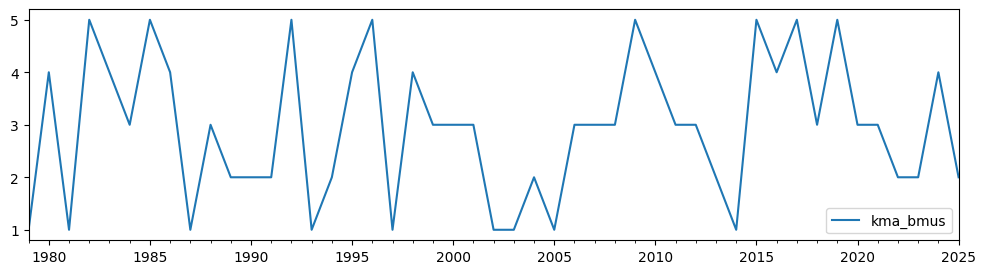

In [7]:
awt.kma_bmus.plot(figsize=(12, 3))

In [8]:
import numpy as np
from bluemath_tk.teslakit.statistical import CopulaSimulation

calculated_PCs = {}
simulated_PCs = {}

for cluster in range(1, awt.num_clusters + 1):
    calculated_PCs[f"{cluster}"] = pca.pcs_df.iloc[
        np.where(awt.kma_bmus == cluster)[0], :
    ].values
    simulated_PCs[f"{cluster}"] = CopulaSimulation(
        U_data=calculated_PCs[f"{cluster}"],
        kernels=["KDE"] * 3,
        num_sim=1000,
    )

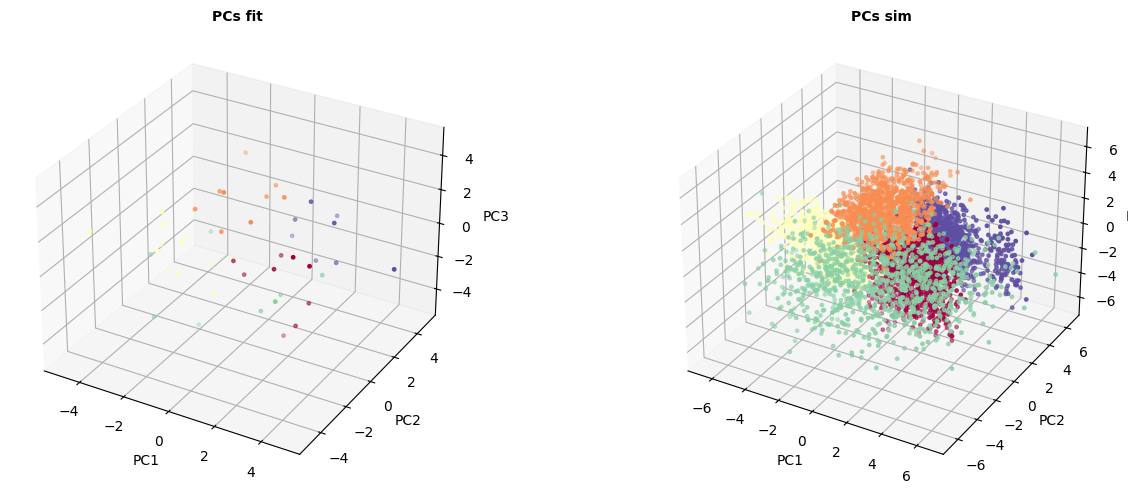

In [9]:
from bluemath_tk.teslakit.plotting.pcs import Plot_PCs_Compare_3D
fig = Plot_PCs_Compare_3D(d_PCs_fit=calculated_PCs, d_PCs_rnd=simulated_PCs)

In [10]:
awt_kma_bmus_df = awt.kma_bmus.copy()
awt_kma_bmus_df.index.name = "time"
awt_kma_bmus_df.columns = ["bmus"]
awt_kma_bmus_ds = awt_kma_bmus_df.to_xarray()
awt_kma_bmus_ds

<xarray.Dataset> Size: 564B
Dimensions:  (time: 47)
Coordinates:
  * time     (time) datetime64[ns] 376B 1979-01-01 1980-01-01 ... 2025-01-01
Data variables:
    bmus     (time) int32 188B 1 4 1 5 4 3 5 4 1 3 2 2 ... 5 4 5 3 5 3 3 2 2 4 2

In [11]:
from bluemath_tk.teslakit.alr import ALR_WRP

alr_terms = {
    "mk_order": 1,
    "constant": True,
    "long_term": False,
    "seasonality": (False, []),
}

alr_model = ALR_WRP(p_base="outputs/awt_alr")
alr_model.SetFitData(
    cluster_size=awt.num_clusters,
    xds_bmus_fit=awt_kma_bmus_ds,
    d_terms_settings=alr_terms,
)
alr_model.FitModel(max_iter=1000)


Fitting autoregressive logistic model ...
Optimization done in 0.01 seconds



/opt/conda/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [12]:
num_sims = 100
y1_sim = 2000
y2_sim = 2100
pca_month_ini = 1
dates_sim = [datetime(y, pca_month_ini, 1) for y in range(y1_sim - 1, y2_sim + 1)]

# launch simulation
ALR_sim = alr_model.Simulate(num_sims=num_sims, time_sim=dates_sim)

# store simulated Annual Weather Types
SST_AWTs_sim = ALR_sim.evbmus_sims.to_dataset()
print(SST_AWTs_sim)


ALR model fit   : 1979-01-01 --- 2025-01-01
ALR model sim   : 1999-01-01 --- 2100-01-01

Launching 100 simulations...

Sim. Num. 100: 100%|██████████| 101/101 [00:00<00:00, 10395.95it/s]

<xarray.Dataset> Size: 82kB
Dimensions:      (time: 102, n_sim: 100)
Coordinates:
  * time         (time) datetime64[ns] 816B 1999-01-01 2000-01-01 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    evbmus_sims  (time, n_sim) int64 82kB 4 4 4 4 4 4 4 4 4 ... 1 2 3 3 3 3 2 4


In [13]:
SST_AWTs_sim.to_netcdf('outputs/AWT_SIM_nsims{0}_{1}_{2}.nc'.format(num_sims, y1_sim, y2_sim))

PerpetualYear bmus comparison skipped.
timedelta (days): Hist - 365 days, 0:00:00, Sim - 365)


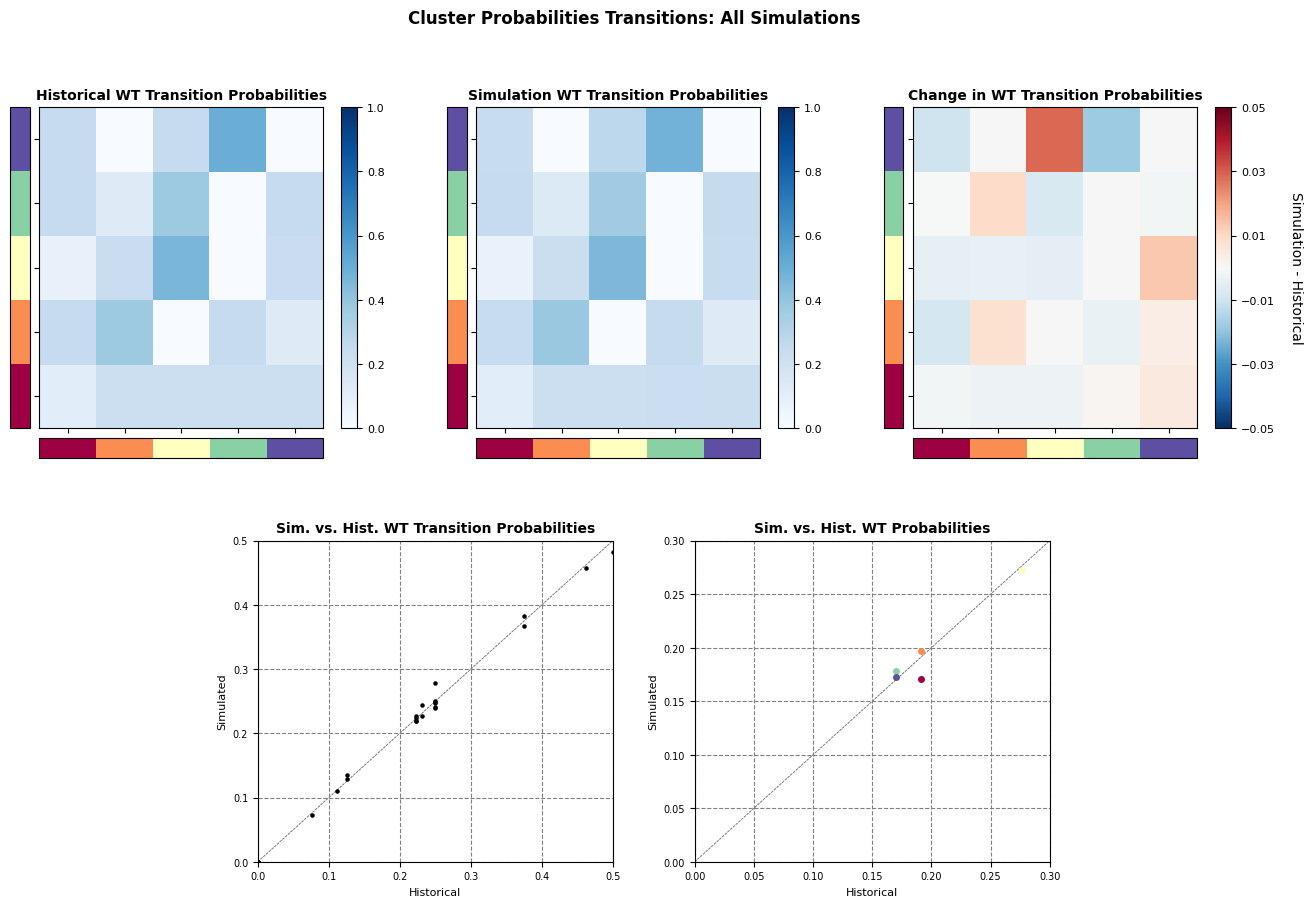

In [14]:
_fig_list = alr_model.Report_Sim()

In [15]:
import xarray as xr

# Generate PCs of the future!

all_simulated_PCs = np.zeros((100, 102, 3))

for i_simulation in SST_AWTs_sim.n_sim:
    for i_bmus, simulated_bmus in enumerate(
        SST_AWTs_sim.sel(n_sim=i_simulation).evbmus_sims.values
    ):
        all_simulated_PCs[i_simulation, i_bmus, :] = simulated_PCs[f"{simulated_bmus}"][
            np.random.randint(1000)
        ]
# all_simulated_PCs = xr.Dataset(
#     {f"PC{i + 1}": (("n_sim", "time"), all_simulated_PCs[:, :, i]) for i in range(3)},
#     {
#         "n_sim": range(100),
#         "time": SST_AWTs_sim.time.astype("datetime64[ns]"),
#     },
# )
all_simulated_PCs = xr.Dataset(
    {"cov_values": (("n_sim", "time", "n_covariates"), all_simulated_PCs)},
    {
        "n_sim": range(100),
        "time": SST_AWTs_sim.time.astype("datetime64[ns]"),
    },
)
all_simulated_PCs

<xarray.Dataset> Size: 246kB
Dimensions:     (n_sim: 100, time: 102, n_covariates: 3)
Coordinates:
  * n_sim       (n_sim) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * time        (time) datetime64[ns] 816B 1999-01-01 2000-01-01 ... 2100-01-01
Dimensions without coordinates: n_covariates
Data variables:
    cov_values  (n_sim, time, n_covariates) float64 245kB -1.994 ... -3.226

In [16]:
 
hist = awt_kma_bmus_ds.bmus.values.astype(int)
hist_years = pd.to_datetime(awt_kma_bmus_ds.time.values).year.values

sim_da = SST_AWTs_sim.evbmus_sims.transpose("n_sim", "time")
sims = sim_da.values.astype(int)                       # (n_sim, time)
sim_years = pd.to_datetime(sim_da.time.values).year.values

K = awt.num_clusters
labels = [f"AWT {k}" for k in range(1, K + 1)]

# Same colors as BlueMath's own plots, if available
try:
    from bluemath_tk.core.plotting.colors import get_cluster_colors
    colors = [tuple(c) for c in get_cluster_colors(K)]
except Exception:
    colors = plt.get_cmap("tab10").colors[:K]

def transition_counts(seq, K):
    C = np.zeros((K, K))
    for a, b in zip(seq[:-1], seq[1:]):
        C[a - 1, b - 1] += 1
    return C

def to_probs(C):
    rs = C.sum(axis=1, keepdims=True)
    return np.divide(C, rs, out=np.zeros_like(C), where=rs > 0)

P_hist = to_probs(transition_counts(hist, K))
P_sim_mean = to_probs(sum(transition_counts(s, K) for s in sims))

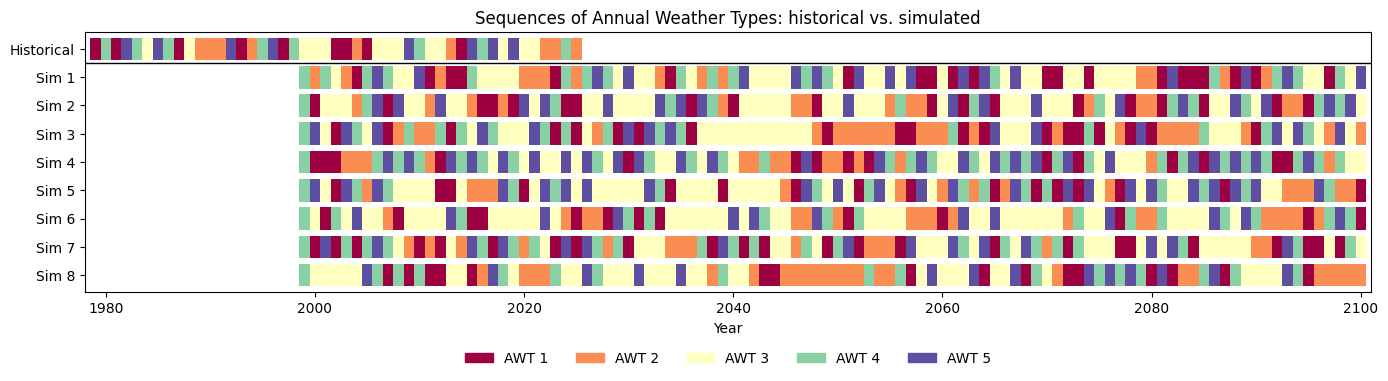

In [17]:
n_show = 8
rows = [("Historical", hist_years, hist)] + \
       [(f"Sim {i + 1}", sim_years, sims[i]) for i in range(n_show)]

fig, ax = plt.subplots(figsize=(14, 4))
for r, (name, yrs, seq) in enumerate(rows):
    for y, s in zip(yrs, seq):
        ax.add_patch(plt.Rectangle((y - 0.5, -r - 0.4), 1, 0.8, color=colors[s - 1], lw=0))

ax.set_yticks([-r for r in range(len(rows))])
ax.set_yticklabels([r[0] for r in rows])
ax.set_ylim(-len(rows) + 0.4, 0.6)
ax.set_xlim(min(hist_years[0], sim_years[0]) - 1, max(hist_years[-1], sim_years[-1]) + 1)
ax.axhline(-0.5, color="k", lw=1)
ax.set_xlabel("Year")
ax.set_title("Sequences of Annual Weather Types: historical vs. simulated")
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(colors, labels)],
          ncol=K, loc="upper center", bbox_to_anchor=(0.5, -0.18), frameon=False)
plt.tight_layout()
plt.show()

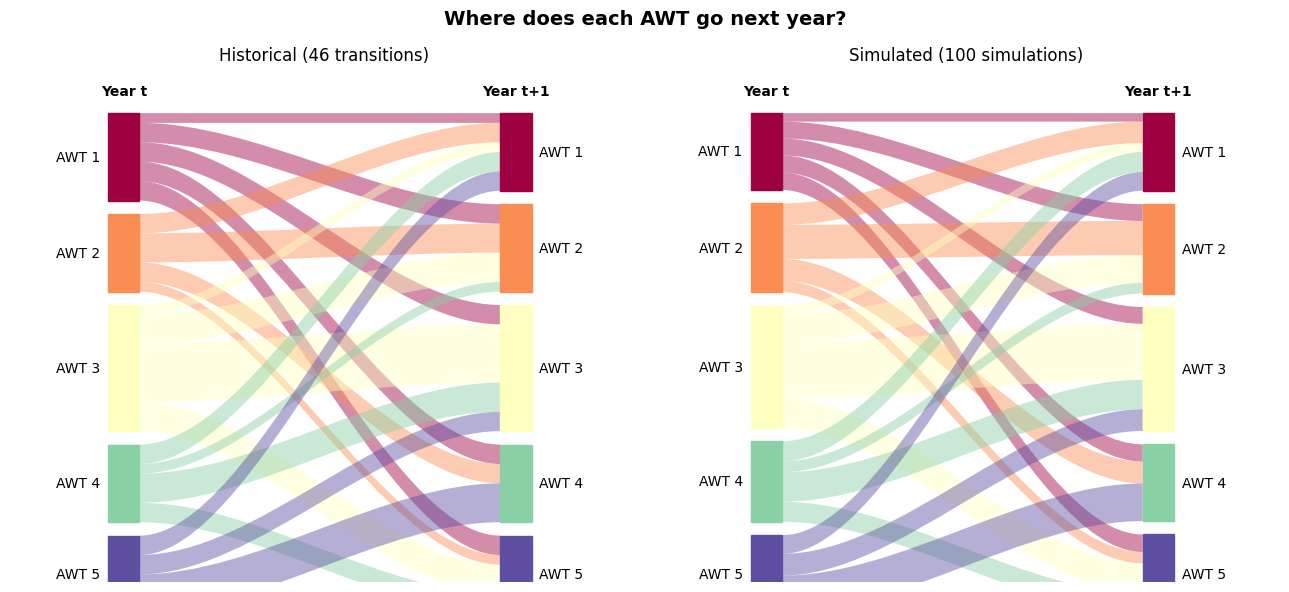

In [18]:
def draw_flow(ax, P, freq, title, gap=0.03):
    x0, x1, w = 0.0, 1.0, 0.08

    def stack(heights):
        tot = heights.sum() + gap * (len(heights) - 1)
        y = 1.0 - (1.0 - tot) / 2 if tot < 1 else 1.0
        tops = []
        for h in heights:
            tops.append(y)
            y -= h + gap
        return np.array(tops)

    flows = freq[:, None] * P                         # band widths, total = 1
    left_h, right_h = flows.sum(1), flows.sum(0)
    left_top, right_top = stack(left_h), stack(right_h)
    l_cur, r_cur = left_top.copy(), right_top.copy()

    for i in range(K):
        for j in range(K):
            h = flows[i, j]
            if h <= 0:
                continue
            ly0, ry0 = l_cur[i], r_cur[j]
            ly1, ry1 = ly0 - h, ry0 - h
            xm0, xm1 = x0 + w + 0.3, x1 - 0.3
            verts = [(x0 + w, ly0), (xm0, ly0), (xm1, ry0), (x1, ry0),
                     (x1, ry1), (xm1, ry1), (xm0, ly1), (x0 + w, ly1), (x0 + w, ly0)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax.add_patch(PathPatch(Path(verts, codes), fc=colors[i], ec="none", alpha=0.45))
            l_cur[i] -= h
            r_cur[j] -= h

    for k in range(K):
        ax.add_patch(plt.Rectangle((x0, left_top[k] - left_h[k]), w, left_h[k], color=colors[k]))
        ax.add_patch(plt.Rectangle((x1, right_top[k] - right_h[k]), w, right_h[k], color=colors[k]))
        ax.text(x0 - 0.02, left_top[k] - left_h[k] / 2, labels[k], ha="right", va="center")
        ax.text(x1 + w + 0.02, right_top[k] - right_h[k] / 2, labels[k], ha="left", va="center")
    ax.text(x0 + w / 2, 1.04, "Year t", ha="center", fontweight="bold")
    ax.text(x1 + w / 2, 1.04, "Year t+1", ha="center", fontweight="bold")
    ax.set_xlim(-0.25, 1.35)
    ax.set_ylim(-0.05, 1.1)
    ax.axis("off")
    ax.set_title(title)

freq_hist = np.bincount(hist[:-1] - 1, minlength=K) / (len(hist) - 1)
freq_sim = np.bincount(sims[:, :-1].ravel() - 1, minlength=K) / sims[:, :-1].size

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
draw_flow(axes[0], P_hist, freq_hist, f"Historical ({len(hist) - 1} transitions)")
draw_flow(axes[1], P_sim_mean, freq_sim, f"Simulated ({sims.shape[0]} simulations)")
fig.suptitle("Where does each AWT go next year?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

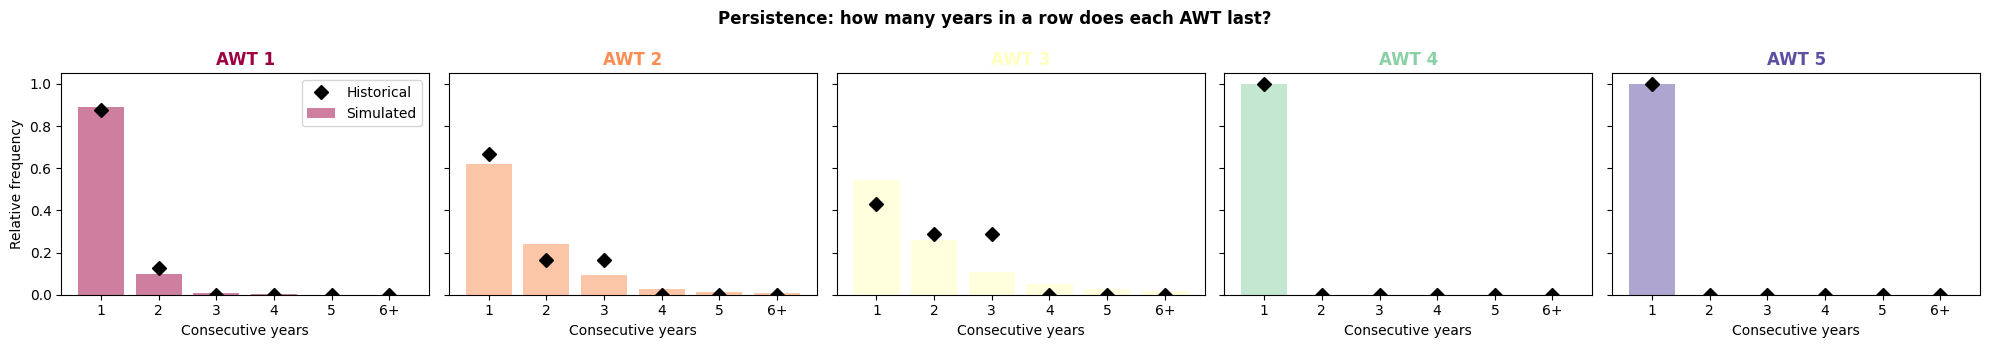

In [20]:
def run_lengths(seq):
    out = {k: [] for k in range(1, K + 1)}
    cur, n = seq[0], 1
    for s in seq[1:]:
        if s == cur:
            n += 1
        else:
            out[cur].append(n)
            cur, n = s, 1
    out[cur].append(n)
    return out

rl_hist = run_lengths(hist)
rl_sim = {k: [] for k in range(1, K + 1)}
for s in sims:
    for k, v in run_lengths(s).items():
        rl_sim[k].extend(v)

max_len = 6
bins = np.arange(1, max_len + 2)
fig, axes = plt.subplots(1, K, figsize=(4 * K, 3.5), sharey=True)
for k, ax in zip(range(1, K + 1), axes):
    hs, _ = np.histogram(np.clip(rl_sim[k], 1, max_len), bins=bins, density=True)
    hh, _ = np.histogram(np.clip(rl_hist[k], 1, max_len), bins=bins, density=True)
    ax.bar(bins[:-1], hs, color=colors[k - 1], alpha=0.5, label="Simulated")
    ax.plot(bins[:-1], hh, "kD", ms=7, label="Historical")
    ax.set_xticks(bins[:-1])
    ax.set_xticklabels([str(b) for b in bins[:-2]] + [f"{max_len}+"])
    ax.set_title(f"AWT {k}", color=colors[k - 1], fontweight="bold")
    ax.set_xlabel("Consecutive years")
axes[0].set_ylabel("Relative frequency")
axes[0].legend()
fig.suptitle("Persistence: how many years in a row does each AWT last?", fontweight="bold")
plt.tight_layout()
plt.show()